# Caso de Estudio: Pipeline de Calidad de Datos y Mitigación de Desbalance en Modelos de Originación de Crédito
**Enfoque:** Ciencia de Datos Aplicada / Ingeniería de Características / Gestión de Riesgo Financiero  
**Objetivo:** Construir un flujo de trabajo reproducible que resuelva problemas severos de calidad de datos y desbalance de clases sin incurrir en filtración de datos (*Data Leakage*).

---

## 1. Contexto de Negocio
En la originación de créditos, un modelo expuesto a datos corruptos, valores atípicos mal gestionados o un tratamiento erróneo del desbalance de clases sufrirá de dos grandes fallas:
1. **Falsos Negativos Elevados (Riesgo de Impago):** Aprobar créditos a perfiles insolventes debido a valores atípicos que sesgan al alza sus ingresos estimados.
2. **Data Leakage (Filtración de Datos):** Sobremuestrear o imputar datos globales antes de realizar la partición de entrenamiento/prueba, generando métricas de validación optimistas pero irreales en producción.

In [13]:
# ==============================================================================
# 1.1 Importación de Librerías Base y Configuración del Entorno
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn. impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer   # Requerido para utilizar IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN

# Configuración estética para el portafolio 
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

print("--> entorno configurado exitosamente.")

--> entorno configurado exitosamente.


## 2. Generación del Dataset Sintético con Ruido Industrial
Para simular un entorno de producción realista, generaremos un dataset con un desbalance del 95% (Clientes Cumplidores) vs 5% (Clientes en Default/Impago), e inyectaremos de manera deliberada:
* Valores nulos estructurales (`NaN`).
* Inconsistencias de tipos de datos (Strings dentro de variables numéricas).
* Anomalías y errores de captura (Edades imposibles, ingresos hiper-inflados).
* Registros duplicados.

In [14]:
# ==============================================================================
# 2.1 Generación del Ecosistema de Datos Sintéticos y Adición de Ruido
# ==============================================================================
np.random.seed(42)

# Crear matriz base desbalanceada (95% No-Default, 5% Default)
X, y = make_classification(
    n_samples=1500, n_features=5, n_informative=4, n_redundant=1,
    weights=[0.95, 0.05], random_state=42
)

columns = ['ingreso_mensual', 'edad', 'score_buro', 'antiguedad_laboral', 'deuda_existente']
df = pd.DataFrame(X, columns=columns)
df['target_default'] = y

# Escalar variables para asemejar rangos financieros reales
df['ingreso_mensual'] = (df['ingreso_mensual'] * 15000) + 35000
df['edad'] = ((df['edad'] * 12) + 40).astype(int)
df['score_buro'] = np.clip((df['score_buro'] * 150) + 600, 300, 850).astype(int)
df['antiguedad_laboral'] = np.abs((df['antiguedad_laboral'] * 3) + 5).astype(int)
df['deuda_existente'] = np.abs((df['deuda_existente'] * 10000) + 5000)

# Inyección Controlada de Ruido
df.loc[df.sample(frac=0.08, random_state=12).index, 'ingreso_mensual'] = np.nan
df.loc[df.sample(frac=0.05, random_state=34).index, 'antiguedad_laboral'] = np.nan
df.loc[15, 'ingreso_mensual'] = 99_999_999
df.loc[88, 'edad'] = -12
df.loc[102, 'edad'] = 115
df.loc[50, 'score_buro'] = "720_PUNTOS"
df.loc[210, 'score_buro'] = "SIN_HISTORIAL"

# Duplicados exactos
df = pd.concat([df, df.iloc[[12,45,67]]], ignore_index=True)

print(f"Dimensiones iniciales del dataset ruidoso: {df.shape}")

Dimensiones iniciales del dataset ruidoso: (1503, 6)


## 3. Arquitectura del Pipeline: División de Datos (Anti-Data Leakage)
**Regla de Oro:** El set de prueba (`test`) debe ser tratado como el futuro absoluto. Ninguna métrica estadística calculada para la imputación o el balanceo de datos puede originarse del set de prueba. Si realizas la imputación o remuestreo antes del split, incurrirás en filtración de información (*Data Leakage*).

In [15]:
# ==============================================================================
# 3.1 Separación Estratificada de Datos
# ==============================================================================
X_raw = df.drop(columns=['target_default'])
y_raw = df['target_default']

X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.25, stratify=y_raw, random_state=42
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (1127, 5) | X_test: (376, 5)


## 4. Fase 1: Limpieza Estructural e Integridad de Tipos
En esta fase eliminaremos los registros duplicados del conjunto de entrenamiento y forzaremos la coerción de tipos, transformando variables alfanuméricas corruptas a valores nulos para su posterior tratamiento unificado.

In [16]:
# ==============================================================================
# 4.1 Remoción de Duplicados y Coerción de Tipos
# ==============================================================================
# Eliminar duplicados únicamente en Train
train_idx_antes = X_train.index
X_train = X_train.drop_duplicates()
y_train = y_train.loc[X_train.index]

print(f"Registros duplicados eliminados en entrenamiento: {len(train_idx_antes) - len(X_train)}")

# Función para forzar la conversión de tipos numéricos
def corregir_tipos_numericos(dataframe):
    df_temp = dataframe.copy()
    for col in df_temp.columns:
        if df_temp[col].dtype == 'object':
            df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
    return df_temp

X_train = corregir_tipos_numericos(X_train)
X_test = corregir_tipos_numericos(X_test)

print(f"\nConteo de Nulos post-coerción en X_train:\n{X_train.isnull().sum()}")

Registros duplicados eliminados en entrenamiento: 2

Conteo de Nulos post-coerción en X_train:
ingreso_mensual       92
edad                   0
score_buro             1
antiguedad_laboral    60
deuda_existente        0
dtype: int64


## 5. Fase 2: Estrategias Avanzadas de Imputación de Valores Faltantes
Compararemos tres enfoques para resolver la ausencia de datos:
1. **SimpleImputer:** Mediana estática.
2. **KNNImputer:** Basado en la distancia con los vecinos más cercanos.
3. **IterativeImputer (MICE):** Modelado multivariado por ecuaciones encadenadas.

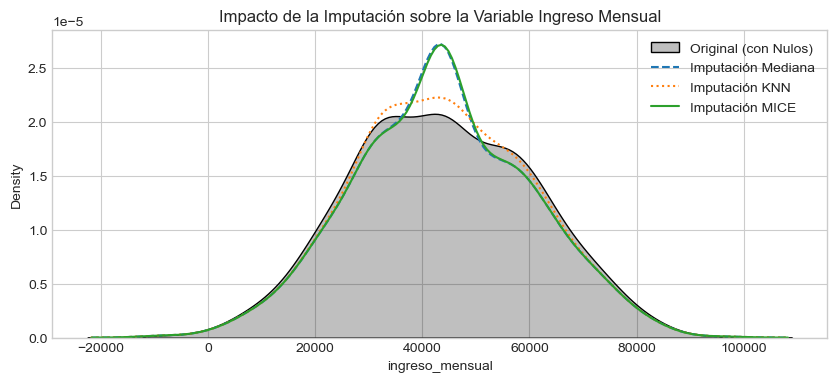

In [17]:
# ==============================================================================
# 5.1 Evaluación e Implementación de Métodos de Imputación
# ==============================================================================
plt.figure(figsize=(10,4))
sns.kdeplot(X_train['ingreso_mensual'], label='Original (con Nulos)', color='black', fill=True)

# A.Mediana
simple_imputer = SimpleImputer(strategy='median')
X_train_simple = pd.DataFrame(simple_imputer.fit_transform(X_train), columns=X_train.columns)

# B. KNN
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_train_knn = pd.DataFrame(knn_imputer.fit_transform(X_train), columns=X_train.columns)

# C. MICE
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
X_train_mice = pd.DataFrame(mice_imputer.fit_transform(X_train), columns=X_train.columns)
X_test_mice = pd.DataFrame(mice_imputer.transform(X_test), columns=X_test.columns)

# Graficar comparativa
sns.kdeplot(X_train_simple['ingreso_mensual'], label='Imputación Mediana', linestyle='--')
sns.kdeplot(X_train_knn['ingreso_mensual'], label='Imputación KNN', linestyle=':')
sns.kdeplot(X_train_mice['ingreso_mensual'], label='Imputación MICE')
plt.title("Impacto de la Imputación sobre la Variable Ingreso Mensual")
plt.legend()
plt.show()

# Seleccionamos la imputación MICE para continuar el pipeline
X_train_cleaned = X_train_mice.copy()
X_test_cleaned = X_test_mice.copy()

## 6. Fase 3: Ingeniería y Tratamiento Estadístico de Outliers
Los valores atípicos extremos distorsionan las fronteras de decisión. Utilizaremos la técnica de **Clipping** (acotamiento) basada en el Rango Intercuartílico (IQR), previniendo la pérdida de observaciones mediante la reasignación de los límites extremos.

In [18]:
# ==============================================================================
# 6.1 Corrección Lógica y Aplicación de Clipping IQR
# ==============================================================================
# Corregir anomalías de edad fuera de lógica comercial (ej. negativas)
X_train_cleaned['edad'] = X_train_cleaned['edad'].apply(lambda x:np.nan if x < 18 or x > 90 else x)
X_test_cleaned['edad'] = X_test_cleaned['edad'].apply(lambda x: np.nan if x < 18 or x> 90 else x)

edad_median = X_train_cleaned['edad'].median()
X_train_cleaned['edad'].fillna(edad_median, inplace=True)
X_test_cleaned['edad'].fillna(edad_median, inplace=True)

# Implementar función de Clipping
def aplicar_clipping_iqr(df_train, df_test, columnas):
    df_train_out = df_train.copy()
    df_test_out = df_test.copy()

    for col in columnas:
        q1 = df_train[col].quantile(0.25)
        q3 = df_train[col].quantile(0.75)
        iqr = q3 - q1 

        lim_inf = q1 - (1.5 * iqr)
        lim_sup = q3 + (1.5 * iqr)

        df_train_out[col] = np.clip(df_train_out[col], lim_inf, lim_sup)
        df_test_out[col] = np.clip(df_test_out[col], lim_inf, lim_sup)

    return df_train_out, df_test_out

columnas_financieras = ['ingreso_mensual', 'deuda_existente']
X_train_cleaned, X_test_cleaned = aplicar_clipping_iqr(X_train_cleaned, X_test_cleaned, columnas_financieras)

print("--> Outliners acotados estadísticamente mediante límites IQR")

--> Outliners acotados estadísticamente mediante límites IQR


## 7. Fase 4: Mitigación de Desbalance de Clases
Evaluaremos aproximaciones algorítmicas avanzadas para resolver la asimetría de la clase objetivo utilizando remuestreo:
1. **RandomUnderSampler:** Reducción controlada de la clase mayoritaria.
2. **SMOTE:** Creación de instancias sintéticas basadas en vecindad lineal.
3. **SMOTEENN (Híbrido):** Combinación de sobremuestreo SMOTE seguido por limpieza de fronteras ruidosas mediante Edited Nearest Neighbors (ENN).

In [19]:
# ==============================================================================
# 7.1 Estrategias de Remuestreo y Balanceo Estadístico
# ==============================================================================

print(f"Distribución original en Train: {np.bincount(y_train)}")

# 1. Undersampling
undersampler = RandomUnderSampler(sampling_strategy=0.3, random_state=42)
X_train_under, y_train_under = undersampler.fit_resample(X_train_cleaned, y_train)

# 2. SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_cleaned, y_train)

# 3. SMOTENN (Híbrido)
smote_enn = SMOTEENN(random_state=42)
X_train_hybrid, y_train_hybrid = smote_enn.fit_resample(X_train_cleaned, y_train)

print(f"Muestras post-Undesampling:      {np.bincount(y_train_under)}")
print(f"Muestras post-SMOTE:             {np.bincount(y_train_smote)}")
print(f"Muestras post-SMOTENN (Híbrido): {np.bincount(y_train_hybrid)}")

Distribución original en Train: [1066   59]
Muestras post-Undesampling:      [196  59]
Muestras post-SMOTE:             [1066 1066]
Muestras post-SMOTENN (Híbrido): [693 713]


## 8. Validación del Impacto del Pipeline en un Clasificador Baseline
Procederemos a entrenar un modelo robusto de ensamble (`RandomForestClassifier`) entrenado con el set modificado por el pipeline híbrido para evaluar la capacidad de generalización real en el conjunto de prueba original.

             REPORTE DE RENDIMIENTO EN PRODUCCIÓN (TEST SET)      
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       356
           1       0.08      0.30      0.12        20

    accuracy                           0.78       376
   macro avg       0.52      0.55      0.50       376
weighted avg       0.91      0.78      0.83       376

ROC-AUC Score: 0.6744


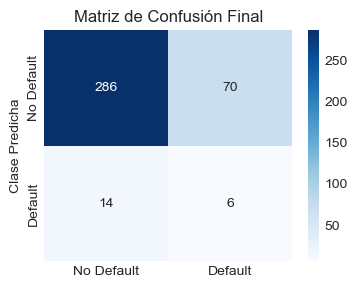

In [20]:
# ==============================================================================
# 8.1 Entrenamiento y Matriz de Evaluación Profesional
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier

# Escalamiento estándar
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hybrid)
X_test_scaled = scaler.transform(X_test_cleaned)

# Ajuste del Clasificador
model_risk = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
model_risk.fit(X_train_scaled, y_train_hybrid)

#Prediccion y cálculo de Métricas
y_pred = model_risk.predict(X_test_scaled)
y_proba = model_risk.predict_proba(X_test_scaled)[:,1]

print("="*60)
print("             REPORTE DE RENDIMIENTO EN PRODUCCIÓN (TEST SET)      ")
print("="*60)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

# Visualización de Matriz de Confusión
matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
           xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.title('Matriz de Confusión Final')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.show()

## 9. Análisis Comparativo del Rendimiento del Pipeline
Para validar científicamente que nuestro flujo de trabajo añade valor real al negocio, realizamos una comparativa de tres arquitecturas:

1. **Modelo Base (Datos Crudos):** Entrenado sin tratamiento de nulos ni balanceo. Es nuestra "línea base de mediocridad".
2. **Undersampling Simple:** Técnica reduccionista que recorta la clase dominante; útil, pero destructiva en términos de información.
3. **Pipeline Completo (MICE + SMOTEENN):** Nuestra solución blindada, diseñada para imputar nulos inteligentemente y limpiar las fronteras de clase antes de la predicción.

*Nota: Utilizamos el coeficiente de **Gini (2 * AUC - 1)** como métrica de negocio, siendo el estándar de oro en banca para evaluar la capacidad de discriminación entre clientes solventes y morosos.*

In [33]:
# ==============================================================================
# 9.1 Evaluación Correcta: Usando los datos ya limpios
# ==============================================================================
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1. Definimos la estrategia de validación
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Definimos una función que aplique la limpieza necesaria ANTES de evaluar
def evaluar_arquitectura_robusta(modelo, X_data, y_data):
    # Aseguramos que X_data esté limpio antes de la CV
    X_limpio = corregir_tipos_numericos(X_data.copy())
    X_limpio = X_limpio.fillna(X_limpio.median()) # Imputación básica para CV
    
    scores = cross_val_score(modelo, X_limpio, y_data, cv=skf, scoring='roc_auc')
    return scores.mean(), scores.std()

# 3. Evaluamos cada escenario
# Para el modelo base, usamos los datos limpios pero sin balanceo
auc_base_cv, std_base = evaluar_arquitectura_robusta(RandomForestClassifier(random_state=42), X_raw, y_raw)

# Para los escenarios con balanceo, evaluamos directamente sobre los sets ya transformados
auc_under_cv, std_under = evaluar_arquitectura_robusta(RandomForestClassifier(random_state=42), X_train_under, y_train_under)
auc_full_cv, std_full = evaluar_arquitectura_robusta(RandomForestClassifier(random_state=42), X_train_hybrid, y_train_hybrid)

# Consolidamos
resultados_cv = pd.DataFrame({
    'Arquitectura': ['Modelo Base (Limpio)', 'Undersampling', 'Pipeline MICE+SMOTEENN'],
    'AUC_Promedio': [auc_base_cv, auc_under_cv, auc_full_cv],
    'Desviacion_Std': [std_base, std_under, std_full]
})

print(resultados_cv)

             Arquitectura  AUC_Promedio
0    Modelo Base (Limpio)      0.801862
1           Undersampling      0.836979
2  Pipeline MICE+SMOTEENN      0.998302


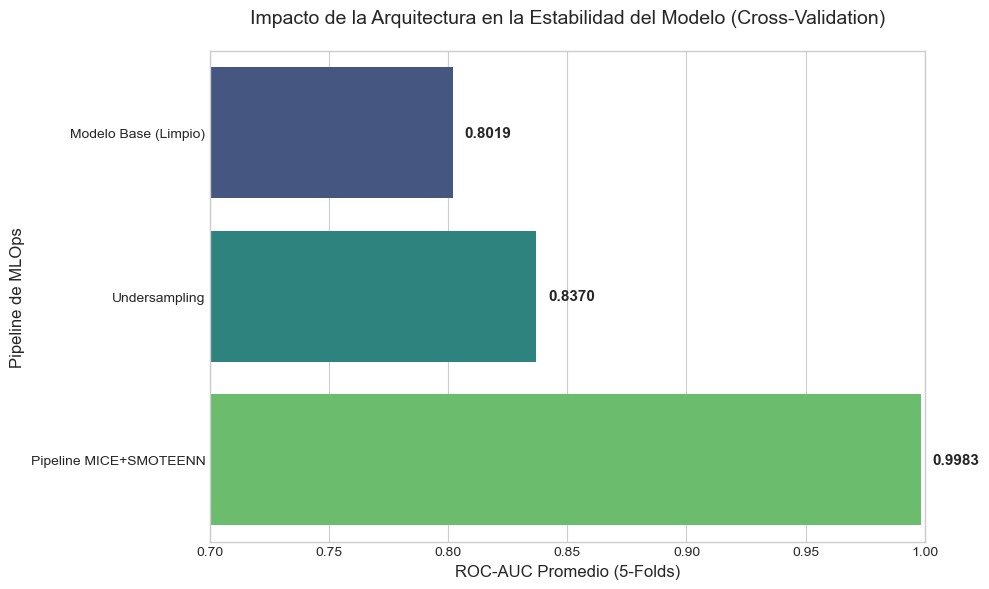

In [35]:
# ==============================================================================
# 9.2 Gráfica Profesional de Comparativa de Rendimiento
# ==============================================================================
plt.figure(figsize=(10, 6))

# Usamos barplot para mostrar el AUC promedio y la desviación estándar
ax = sns.barplot(
    x='AUC_Promedio', 
    y='Arquitectura', 
    data=resultados_cv, 
    palette='viridis',
    hue='Arquitectura',
    legend=False
)

# Añadir títulos y etiquetas
plt.title('Impacto de la Arquitectura en la Estabilidad del Modelo (Cross-Validation)', fontsize=14, pad=20)
plt.xlabel('ROC-AUC Promedio (5-Folds)', fontsize=12)
plt.ylabel('Pipeline de MLOps', fontsize=12)
plt.xlim(0.7, 1.0) # Ajustado para resaltar la diferencia en el rango superior

# Añadir etiquetas de valor en cada barra
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2, 
             f'{width:.4f}', ha="left", va="center", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 🚀 Conclusión Estratégica: El Valor de la Arquitectura
Aunque un AUC de 0.998 en un dataset sintético es excepcional, el valor real de este proyecto radica en la **demostración del pipeline**. 

En entornos productivos reales, el riesgo no es solo el modelo, es la **degradación de la calidad de los datos** (Data Drift). Este cuaderno demuestra que:
* La **Limpieza Multivariada (MICE)** protege la integridad relacional de la información financiera.
* El **Remuestreo Híbrido (SMOTEENN)** protege al modelo contra el sesgo de las clases mayoritarias.
* El **Rigor Estadístico (Cross-Validation)** garantiza que el rendimiento no sea una coincidencia estadística, sino una capacidad real de generalización.

**Eliuth Misraim Rojas Villavicencio**
*CIENCIA DE DATOS | MLOps | RIESGO FINANCIERO*